# Entrega individual 2

## Consigna

Realizar un EDA básico del dataset seleccionado:
- Estadística descriptiva
- Tipos de variables
- Relaciones entre variables
- Incluir al menos 3 gráficos

Hablar de que se va a hacer un analisis de las cantidades de profesionales principalmente.

In [2]:
import pandas as pd

### Carga de dataset
Además de los valores crudos del dataset, se utiliza una función de mapeo que toma los códigos de las columnas y las cambia por una normalización de su descripción. El diccionario original se encuentra [disponible en este enlace](https://www.datos.gob.ar/dataset/sedronar-primer-relevamiento-nacional-dispositivos---2022/archivo/sedronar_8.2). Se usó un LLM para crear el mapeo y se corrigió manualmente

In [3]:
from mapeos.mappers_dispositivos import map_columns
raw_data = pd.read_csv('data/base-primer-relev-dispositivos.csv', encoding="latin-1")
data = map_columns(raw_data)
data.head(5)

,id_dispositivo,provincia,atiende_en,dependencia_institucional,financiamiento_beca_sedronar,financiamiento_otras_becas,financiamiento_directo,financiamiento_donaciones,financiamiento_obras_sociales,financiamiento_prepaga,...,dificultad_covid_otras_dificultades,encuentra_barreras_ley_sm,articula_consejo_consultivo_honorario,articula_organo_revision_ley_nacional,articula_unidad_letrados,articula_organizaciones_usuarios,articula_organo_revision_provincial,articula_secretaria_ddhh_nacion,articula_no_requirieron,articula_otro
0,13553967419,Buenos Aires,Salud mental y consumos problemáticos,Organizaciones de la Sociedad Civil,Pública a través de becas de Sedronar,,,,,,...,,"No, considero que la ley se garantiza plenamente.",,,,,,,"No articulamos, porque no hubo situaciones que...",
1,13573413402,Buenos Aires,Salud mental y consumos problemáticos,Mixto,Pública a través de becas de Sedronar,,,,,,...,,"Sí, en la red de articulación con otros actore...",,,,,,,"No articulamos, porque no hubo situaciones que...",
2,118069172458,Buenos Aires,Salud mental y consumos problemáticos,Público municipal,,,Pública por financiamiento directo,,,,...,Otras dificultades (especifique),"Sí, en la red de articulación con otros actore...",,,,,,,"No articulamos, porque no hubo situaciones que...",
3,13577920209,Buenos Aires,Salud mental y consumos problemáticos,Mixto,,,Pública por financiamiento directo,,,,...,,"No, considero que la ley se garantiza plenamente.",,,,,,,"No articulamos, porque no hubo situaciones que...",
4,13500631102,Buenos Aires,Consumos problemáticos,Público municipal,Pública a través de becas de Sedronar,,,,,,...,,"Sí, en la red de articulación con otros actore...",,,,,,,"No articulamos, porque no hubo situaciones que...",


En caso de querer consultar el código original se puede hacer

In [4]:
import mapeos.mappers_dispositivos as cols_info

#original
print(cols_info.get_mapped_columns()[:5])
#original: reemplazo (en el ejemplo se seleccionan solamente 5)
print(dict(list(cols_info.get_columns_mapping().items())[:5]))

['respondent_id', 'q0011', 'q0021', 'q0022', 'q0023_0001']
{'respondent_id': 'id_dispositivo', 'q0011': 'provincia', 'q0021': 'atiende_en', 'q0022': 'dependencia_institucional', 'q0023_0001': 'financiamiento_beca_sedronar'}


### Tipos de variables

In [5]:
data.dtypes.value_counts()

object    229
int64       1
Name: count, dtype: int64

A priori, figura que todas las variables son strings. Esto no es consistente con los nombres de las mismas, por ejemplo todas las variables de cantidad de profesionales

In [6]:
cantidades_profesionales = [col for col in data.columns if "cantidad" in col]
data[cantidades_profesionales]

,cantidad_medico_clinico,cantidad_medico_psiquiatra,cantidad_medico_psiquiatra_infanto_juvenil,cantidad_medico_toxicologico,cantidad_medico_infectologo,cantidad_psicologo,cantidad_trabajador_social,cantidad_enfermero,cantidad_terapista_ocupacional,cantidad_nutricionista,...,cantidad_tallerista,cantidad_personal_administrativo,cantidad_personal_seguridad,cantidad_personal_mantenimiento,cantidad_personal_cocina,cantidad_personal_maestranza,cantidad_personal_apoyo_religioso,cantidad_pasante_grado,cantidad_pasante_posgrado,cantidad_acompanante_terapeutico
0,0,0,0,0,0,1,1,0,0,0,...,3,4,0,2,0,0,0,0,0,0
1,0,0,0,0,0,6,3,0,0,0,...,0,2,0,0,0,0,0,2,0,0
2,3,0,0,0,0,2,1,1,0,1,...,0,1,0,0,0,0,0,3,0,0
3,1,0,0,0,0,3,1,1,0,0,...,0,1,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1793,0,0,0,0,0,1,1,0,0,0,...,0,2,0,0,5,0,0,0,0,0
1794,,,,,,,,,,,...,,,,,,,,,,
1795,0,0,0,0,0,1,1,0,1,0,...,5,1,0,0,2,0,1,0,0,3
1796,,,,,,,,,,,...,,,,,,,,,,


Analizo el rango de valores de todas las columnas para encontrar el problema. Resulta que hay dos problemas:
- Valores vacíos que figuran como `" "`
- `"Más de 20"` como categoría residual que vuelve categórica una variable numérica discreta

In [7]:
pd.Series(list(set(data[cantidades_profesionales].values.flatten()))).sort_values()

10             
6             0
20            1
2            10
4            11
21           12
9            13
13           14
5            15
17           16
14           17
3            18
18           19
15            2
8            20
0             3
19            4
1             5
22            6
16            7
12            8
11            9
7     Más de 20
dtype: object

In [8]:
pd.Index(set(data[cantidades_profesionales].values.flatten()))

Index(['3', '5', '10', '18', '11', '15', '0', 'Más de 20', '20', '13', ' ',
       '9', '8', '14', '17', '2', '7', '16', '19', '4', '1', '12', '6'],
      dtype='object')

#### Análisis de `" "`

In [9]:
data[cantidades_profesionales][data[cantidades_profesionales].isin([" "])].dropna(how="all")

,cantidad_medico_clinico,cantidad_medico_psiquiatra,cantidad_medico_psiquiatra_infanto_juvenil,cantidad_medico_toxicologico,cantidad_medico_infectologo,cantidad_psicologo,cantidad_trabajador_social,cantidad_enfermero,cantidad_terapista_ocupacional,cantidad_nutricionista,...,cantidad_tallerista,cantidad_personal_administrativo,cantidad_personal_seguridad,cantidad_personal_mantenimiento,cantidad_personal_cocina,cantidad_personal_maestranza,cantidad_personal_apoyo_religioso,cantidad_pasante_grado,cantidad_pasante_posgrado,cantidad_acompanante_terapeutico
1530,,,,,,,,,,,...,,,,,,,,,,
1531,,,,,,,,,,,...,,,,,,,,,,
1533,,,,,,,,,,,...,,,,,,,,,,
1537,,,,,,,,,,,...,,,,,,,,,,
1543,,,,,,,,,,,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788,,,,,,,,,,,...,,,,,,,,,,
1792,,,,,,,,,,,...,,,,,,,,,,
1794,,,,,,,,,,,...,,,,,,,,,,
1796,,,,,,,,,,,...,,,,,,,,,,


Cuando no está declarado el número en una categoría, no está declarado en ninguna

In [10]:
missing_value_index = data[cantidades_profesionales][data[cantidades_profesionales].isin([" "])].dropna(how="all").index
missing_value_data = data.iloc[missing_value_index,:]
missing_value_data

,id_dispositivo,provincia,atiende_en,dependencia_institucional,financiamiento_beca_sedronar,financiamiento_otras_becas,financiamiento_directo,financiamiento_donaciones,financiamiento_obras_sociales,financiamiento_prepaga,...,dificultad_covid_otras_dificultades,encuentra_barreras_ley_sm,articula_consejo_consultivo_honorario,articula_organo_revision_ley_nacional,articula_unidad_letrados,articula_organizaciones_usuarios,articula_organo_revision_provincial,articula_secretaria_ddhh_nacion,articula_no_requirieron,articula_otro
1530,114056217684,Neuquén,Salud mental,Público provincial,,,,,,,...,,,,,,,,,,
1531,114056640218,Jujuy,Salud mental,Público provincial,,,Pública por financiamiento directo,,,,...,,,,,,,,,,
1533,114064774992,Entre Ríos,Salud mental,Público nacional,,,Pública por financiamiento directo,,,,...,,,,,,,,,,
1537,114066168051,Santa Fe,Salud mental y consumos problemáticos,Público provincial,,,Pública por financiamiento directo,,,,...,,,,,,,,,,
1543,114075300925,Neuquén,Salud mental y consumos problemáticos,Público provincial,,,,,,,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788,13584077684,Buenos Aires,Salud mental y consumos problemáticos,Público municipal,,,Pública por financiamiento directo,,,,...,,,,,,,,,,
1792,13589193458,Misiones,Salud mental,Público provincial,,,Pública por financiamiento directo,,Seguridad Social (Obras Sociales),,...,,,,,,,,,,
1794,13590410801,San Juan,Consumos problemáticos,Organizaciones de la Sociedad Civil,,,,Donaciones,,,...,,,,,,,,,,
1796,13590601136,Entre Ríos,Consumos problemáticos,Mixto,Pública a través de becas de Sedronar,,,Donaciones,Seguridad Social (Obras Sociales),,...,,,,,,,,,,


Voy a tratar de visualizar si esto es por haber completado mal el formulario. Es decir, si se condice con casos de abandono

In [11]:
def coerce_values(series: pd.Series) -> pd.Series:
    #Transformo todos los " " en 0 y el resto en 1
    return series.apply(lambda val: 0 if val == " " else 1)

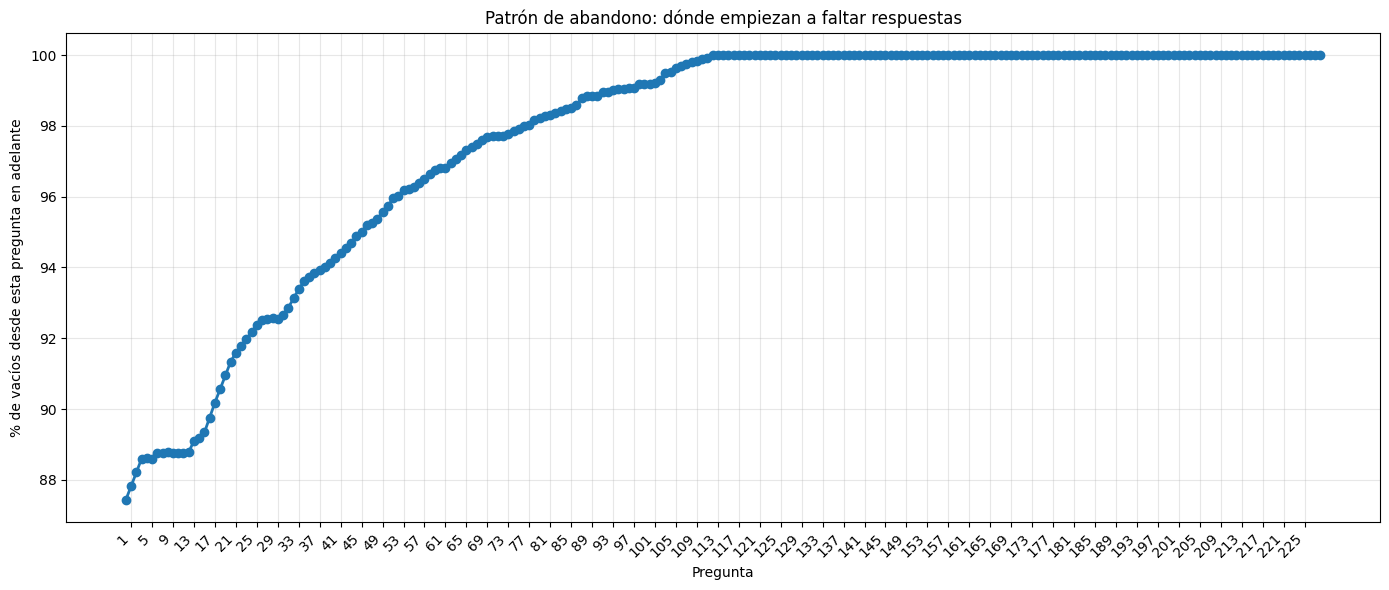

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
matriz = missing_value_data.set_index("id_dispositivo").apply(coerce_values)
# Calcular para cada pregunta: qué porcentaje de entradas están vacías DESDE esa pregunta en adelante
abandonos = []
for col_idx, col in enumerate(matriz.columns):
    # Desde esta pregunta en adelante, qué % está vacío
    submatriz = matriz.iloc[:, col_idx:]
    porcentaje_vacio = (submatriz == 0).sum(axis=1).mean() / len(submatriz.columns) * 100
    abandonos.append(porcentaje_vacio)

# Visualizar el patrón de abandono
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(matriz.columns, abandonos, marker='o', linewidth=2, markersize=6)
ax.set_xlabel('Pregunta')
ax.set_xticks(range(1,len(matriz.columns),4))
ax.set_xticklabels(range(1,len(matriz.columns),4))
ax.set_ylabel('% de vacíos desde esta pregunta en adelante')
ax.set_title('Patrón de abandono: dónde empiezan a faltar respuestas')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45 ,ha='right')
plt.tight_layout()
plt.show()

In [13]:
import plotly.graph_objects as go
import numpy as np

# Crear matriz transpuesta
matriz_transpuesta = matriz.T.reset_index(drop=True)

# Crear heatmap con Plotly
fig_heatmap = go.Figure(data=go.Heatmap(
    z=matriz_transpuesta.values,
    x=list(range(len(matriz))),  # Solo números: entradas
    y=list(range(1, len(matriz_transpuesta) + 1)),  # Números de pregunta (1-indexed)
    customdata=np.dstack((
        np.tile(matriz.columns, (len(matriz), 1)).T,  # Nombres de preguntas
        np.tile(range(len(matriz)), (len(matriz_transpuesta), 1))  # Números de entrada
    )),
    hovertemplate='<b>Pregunta:</b> %{customdata[0]}<br><b>Entrada:</b> %{customdata[1]}<br><b>Respondido:</b> %{z}<extra></extra>',
    colorscale='RdYlGn',
    colorbar=dict(title='Respondido')
))

fig_heatmap.update_layout(
    title='Cascada de respuestas por pregunta',
    xaxis_title='Número de Entrada',
    yaxis_title='Número de Pregunta',
    height=800,
    width=1400,
    xaxis=dict(showticklabels=False),  # Sin labels en X
    yaxis=dict(showticklabels=True, autorange='reversed',dtick=5),  # Mostrar labels en Y
)

fig_heatmap.show()

##### Conclusión
Queda claro que son casos de abandono de cuestionario. Por eso se eliminan del dataset todos los registros que no tienen respuestas. Se reemplazará `" "` por `NaN`

In [14]:
data = data.replace(" ", np.nan)
print(data.shape, data.dropna(how="all", subset=cantidades_profesionales).shape)
data = data.dropna(how="all", subset=cantidades_profesionales, axis=0)

(1798, 230) (1676, 230)


#### Análisis de `Más de 20`

In [34]:
for col in cantidades_profesionales:
    count = data[cantidades_profesionales][data[cantidades_profesionales].isin(["Más de 20"])].T.dropna(axis=1,how="all").T[col].value_counts()
    if count.any():
        print(count)

cantidad_medico_clinico
Más de 20    2
Name: count, dtype: int64
cantidad_medico_psiquiatra
Más de 20    6
Name: count, dtype: int64
cantidad_psicologo
Más de 20    18
Name: count, dtype: int64
cantidad_trabajador_social
Más de 20    2
Name: count, dtype: int64
cantidad_enfermero
Más de 20    28
Name: count, dtype: int64
cantidad_psicopedagogo
Más de 20    2
Name: count, dtype: int64
cantidad_operador_socioterapeutico
Más de 20    4
Name: count, dtype: int64
cantidad_operador_calle
Más de 20    4
Name: count, dtype: int64
cantidad_docente
Más de 20    3
Name: count, dtype: int64
cantidad_tallerista
Más de 20    13
Name: count, dtype: int64
cantidad_personal_administrativo
Más de 20    14
Name: count, dtype: int64
cantidad_personal_seguridad
Más de 20    2
Name: count, dtype: int64
cantidad_personal_mantenimiento
Más de 20    4
Name: count, dtype: int64
cantidad_personal_cocina
Más de 20    4
Name: count, dtype: int64
cantidad_personal_maestranza
Más de 20    7
Name: count, dtype: int64

In [46]:
# Crear matriz booleana: 1 si es "Más de 20", 0 si no
matriz_mas_de_20 = (data[cantidades_profesionales] == "Más de 20").astype(int)

# Sumar por cada columna
resultado = matriz_mas_de_20.sum()

resultado_df = pd.DataFrame({
    'Profesional': resultado.index,
    'Cantidad_mas_de_20': resultado.values,    
    'Proporcion': resultado / len(data[cantidades_profesionales])

}).sort_values('Cantidad_mas_de_20', ascending=False).reset_index(drop=True)

resultado_df

,Profesional,Cantidad_mas_de_20,Proporcion
0,cantidad_enfermero,28,0.016706
1,cantidad_psicologo,18,0.010740
2,cantidad_personal_administrativo,14,0.008353
3,cantidad_tallerista,13,0.007757
4,cantidad_pasante_posgrado,7,0.004177
5,cantidad_personal_maestranza,7,0.004177
6,cantidad_medico_psiquiatra,6,0.003580
7,cantidad_operador_calle,4,0.002387
8,cantidad_operador_socioterapeutico,4,0.002387
9,cantidad_personal_cocina,4,0.002387


In [49]:
# Crear matriz booleana
matriz_mas_de_20 = (data[cantidades_profesionales] == "Más de 20").astype(int)

# Contar "Más de 20" por columna
cantidad_mas_de_20 = matriz_mas_de_20.sum()

# Contar valores no nulos por columna (total de respuestas por profesional)
total_respuestas = data[cantidades_profesionales].notna().sum()

# Calcular proporción intracategoría
proporcion_intracategoria = cantidad_mas_de_20 / total_respuestas

# Crear DataFrame
resultado_df = pd.DataFrame({
    'Profesional': cantidad_mas_de_20.index,
    'Cantidad_mas_de_20': cantidad_mas_de_20.values,
    'Total_respuestas': total_respuestas.values,
    'Proporcion_intracategoria': proporcion_intracategoria.values
}).sort_values('Cantidad_mas_de_20', ascending=False).reset_index(drop=True)

resultado_df

,Profesional,Cantidad_mas_de_20,Total_respuestas,Proporcion_intracategoria
0,cantidad_enfermero,28,1676,0.016706
1,cantidad_psicologo,18,1676,0.010740
2,cantidad_personal_administrativo,14,1676,0.008353
3,cantidad_tallerista,13,1676,0.007757
4,cantidad_pasante_posgrado,7,1676,0.004177
5,cantidad_personal_maestranza,7,1676,0.004177
6,cantidad_medico_psiquiatra,6,1676,0.003580
7,cantidad_operador_calle,4,1676,0.002387
8,cantidad_operador_socioterapeutico,4,1676,0.002387
9,cantidad_personal_cocina,4,1676,0.002387


En todos los casos representa menos del 0.02% de cada categoría. Se decide eliminar esas entradas del dataset porque no se puede saber si son 21 o 100. Ahora se puede analizar numericamente la cantidad de profesionales

In [ ]:
# Crear máscara booleana: True donde hay "Más de 20"
mas_de_20 = (data[cantidades_profesionales] == "Más de 20").any(axis=1)

# Dropear las filas que tienen al menos un "Más de 20"
data = data[~mas_de_20]
data[cantidades_profesionales] = data[cantidades_profesionales].astype(int)

In [56]:
data[cantidades_profesionales].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1606 entries, 0 to 1795
Data columns (total 24 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   cantidad_medico_clinico                     1606 non-null   int32
 1   cantidad_medico_psiquiatra                  1606 non-null   int32
 2   cantidad_medico_psiquiatra_infanto_juvenil  1606 non-null   int32
 3   cantidad_medico_toxicologico                1606 non-null   int32
 4   cantidad_medico_infectologo                 1606 non-null   int32
 5   cantidad_psicologo                          1606 non-null   int32
 6   cantidad_trabajador_social                  1606 non-null   int32
 7   cantidad_enfermero                          1606 non-null   int32
 8   cantidad_terapista_ocupacional              1606 non-null   int32
 9   cantidad_nutricionista                      1606 non-null   int32
 10  cantidad_psicopedagogo                   

## Analisis de cantidades de profesonales

In [64]:
data[cantidades_profesionales].describe().T.sort_values(by="mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
cantidad_psicologo,1606.0,2.429016,2.378435,0.0,1.0,2.0,3.0,20.0
cantidad_tallerista,1606.0,2.112702,2.959814,0.0,0.0,1.0,4.0,20.0
cantidad_operador_socioterapeutico,1606.0,1.328144,2.513771,0.0,0.0,0.0,2.0,17.0
cantidad_personal_administrativo,1606.0,1.279577,1.665757,0.0,0.0,1.0,2.0,17.0
cantidad_trabajador_social,1606.0,1.076588,1.322600,0.0,0.0,1.0,1.0,20.0
cantidad_enfermero,1606.0,0.971980,2.497318,0.0,0.0,0.0,1.0,20.0
cantidad_personal_cocina,1606.0,0.762765,1.937113,0.0,0.0,0.0,1.0,16.0
cantidad_personal_mantenimiento,1606.0,0.737235,1.507430,0.0,0.0,0.0,1.0,16.0
cantidad_personal_maestranza,1606.0,0.575965,1.448220,0.0,0.0,0.0,1.0,15.0
cantidad_operador_calle,1606.0,0.546077,1.637582,0.0,0.0,0.0,0.0,20.0


In [83]:
def plot_distribucion_profesionales(data, cantidades_profesionales, tipo="combinado"):
    """
    Genera un gráfico interactivo de distribución de cantidades por tipo de profesional.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame con los datos
    cantidades_profesionales : list
        Lista de columnas a graficar
    tipo : str
        Tipo de gráfico: "violin", "box" o "combinado" (default)
    """
    import plotly.graph_objects as go
    from ipywidgets import widgets
    from IPython.display import display

    # Preparar datos
    df_desc = data[cantidades_profesionales].describe().T.sort_values(by="mean", ascending=False)
    categorias_ordenadas = df_desc.index.tolist()
    top5 = categorias_ordenadas[:5]

    # Limpiar nombres para el display
    def limpiar_nombre(col):
        return col.replace("cantidad_", "").replace("_", " ").title()

    nombres_display = {col: limpiar_nombre(col) for col in categorias_ordenadas}

    # Crear figura según tipo
    def crear_figura(categorias_seleccionadas):
        fig = go.Figure()

        for col in categorias_seleccionadas:
            valores = data[col].dropna()
            hover = (
                f'<b>{nombres_display[col]}</b><br>'
                'Valor: %{y}<br>'
                f'Media: {valores.mean():.2f}<br>'
                f'Desvío: {valores.std():.2f}<extra></extra>'
            )

            if tipo == "violin":
                fig.add_trace(go.Violin(
                    y=valores,
                    name=nombres_display[col],
                    box_visible=False,
                    meanline_visible=True,
                    hovertemplate=hover
                ))

            elif tipo == "box":
                fig.add_trace(go.Box(
                    y=valores,
                    name=nombres_display[col],
                    hovertemplate=hover
                ))

            elif tipo == "combinado":
                fig.add_trace(go.Violin(
                    y=valores,
                    name=nombres_display[col],
                    box_visible=True,
                    meanline_visible=True,
                    hovertemplate=hover
                ))

            else:
                raise ValueError(f"tipo debe ser 'violin', 'box' o 'combinado'. Recibido: '{tipo}'")

        fig.update_layout(
            title=f'Distribución de cantidades por profesional ({tipo})',
            yaxis=dict(title='Cantidad', range=[-2, 20], dtick=2),
            xaxis=dict(title='Tipo de Profesional'),
            showlegend=False,
            height=600,
            width=1200,
            violingap=0.2,
            violinmode='group'
        )

        return fig

    # Widget de selección
    selector = widgets.SelectMultiple(
        options=[(nombres_display[col], col) for col in categorias_ordenadas],
        value=top5,
        description='Profesionales:',
        layout=widgets.Layout(width='280px', height='400px'),
        style={'description_width': 'initial'}
    )

    output = widgets.Output()

    with output:
        crear_figura(top5).show()

    def on_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            output.clear_output(wait=True)
            with output:
                crear_figura(list(change['new'])).show()

    selector.observe(on_change)

    label = widgets.HTML("<b>Seleccioná categorías:<br><small>(Ctrl+Click para múltiples)</small></b>")
    panel = widgets.VBox([label, selector], layout=widgets.Layout(margin='40px 10px 0 0'))
    dashboard = widgets.HBox([panel, output])

    display(dashboard)
plot_distribucion_profesionales(data, cantidades_profesionales, "box")

In [102]:
def filtrar_iqr(data, columnas):
    """
    Filtra los valores fuera del IQR para un conjunto de columnas.

    Parameters
    ----------
    data : pd.DataFrame
        DataFrame con los datos
    columnas : list
        Lista de columnas numéricas a filtrar
    
    Returns
    -------
    pd.DataFrame
        DataFrame con los valores fuera del IQR reemplazados por NaN
    """
    data_filtrado = data.copy()
    
    for col in columnas:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        data_filtrado[col] = data[col].where(data[col].between(lower, upper))
    
    return data_filtrado

data_iqr = filtrar_iqr(data, cantidades_profesionales)
rangos = {}
for col in cantidades_profesionales:
    rangos[col] = [data_iqr[cantidades_profesionales][col].min(),data_iqr[cantidades_profesionales][col].max()]
rangos

{'cantidad_medico_clinico': [0.0, 2.0],
 'cantidad_medico_psiquiatra': [0.0, 2.0],
 'cantidad_medico_psiquiatra_infanto_juvenil': [0.0, 0.0],
 'cantidad_medico_toxicologico': [0.0, 0.0],
 'cantidad_medico_infectologo': [0.0, 0.0],
 'cantidad_psicologo': [0.0, 6.0],
 'cantidad_trabajador_social': [0.0, 2.0],
 'cantidad_enfermero': [0.0, 2.0],
 'cantidad_terapista_ocupacional': [0.0, 0.0],
 'cantidad_nutricionista': [0.0, 0.0],
 'cantidad_psicopedagogo': [0.0, 0.0],
 'cantidad_operador_socioterapeutico': [0.0, 5.0],
 'cantidad_operador_calle': [0.0, 0.0],
 'cantidad_docente': [0.0, 0.0],
 'cantidad_tallerista': [0.0, 10.0],
 'cantidad_personal_administrativo': [0.0, 5.0],
 'cantidad_personal_seguridad': [0.0, 0.0],
 'cantidad_personal_mantenimiento': [0.0, 2.0],
 'cantidad_personal_cocina': [0.0, 2.0],
 'cantidad_personal_maestranza': [0.0, 2.0],
 'cantidad_personal_apoyo_religioso': [0.0, 0.0],
 'cantidad_pasante_grado': [0.0, 0.0],
 'cantidad_pasante_posgrado': [0.0, 0.0],
 'cantidad_a